In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

In [7]:
housing=fetch_california_housing()
data=pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]=housing.target

In [16]:
X=data[['AveRooms']].values
y=data['Price'].values

In [17]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
w=0
b=0
learning_rate=0.01
epochs=1000
cost_history=[]

n=len(X_train_scaled)

for i in range(epochs):
    y_pred=w * X_train_scaled.flatten()+b
    cost=(1/(2*n)) * np.sum((y_pred - y_train)**2)
    cost_history.append(cost)
    
    dw=(1/n)*np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db=(1/n)*np.sum(y_pred - y_train)
    w=w-learning_rate*dw
    b=b-learning_rate*db
    
    if i%100==0:
        print(f"Epoch {i}, Cost= {cost:.4f}")
        
y_pred_gd= w * X_test_scaled.flatten() + b


Epoch 0, Cost= 2.8149
Epoch 100, Cost= 0.9414
Epoch 200, Cost= 0.6904
Epoch 300, Cost= 0.6568
Epoch 400, Cost= 0.6523
Epoch 500, Cost= 0.6517
Epoch 600, Cost= 0.6516
Epoch 700, Cost= 0.6516
Epoch 800, Cost= 0.6516
Epoch 900, Cost= 0.6516


In [50]:
print("Gradient Descent")
print("-----------------")
print("Weight:",w)
print("Bias:",b)
print("MSE:",mean_squared_error(y_test,y_pred_gd))
print("R2 score:",r2_score(y_test,y_pred_gd))


Gradient Descent
-----------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.292327655590046
R2 score: 0.013798228607320828


In [51]:
X_train_ne =np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne=np.c_[np.ones((len(X_test),1)),X_test]

theta=np.linalg.inv(X_train_ne.T@X_train_ne)@X_train_ne.T@y_train
y_pred_ne=X_test_ne@theta

In [52]:
print("\nNormal Equation")
print("------------------")
print("intercept:",theta[0])
print("slope:",theta[1])
print("MSE:",mean_squared_error(y_test,y_pred_ne))
print("R2 score:",r2_score(y_test,y_pred_ne))



Normal Equation
------------------
intercept: 1.6547622685968417
slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 score: 0.013795337532284901


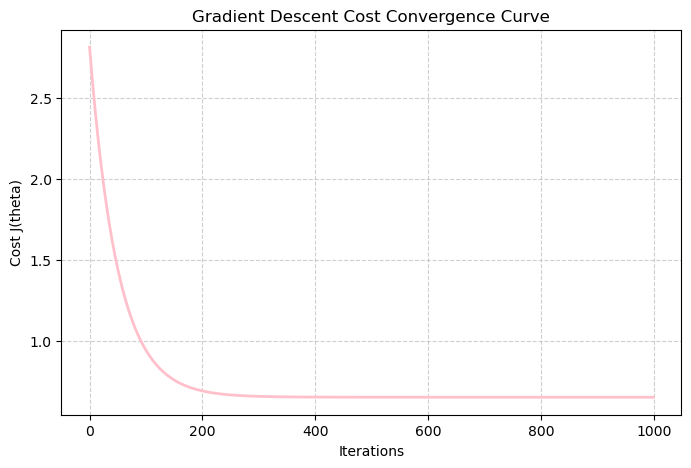

In [53]:
plt.figure(figsize=(8,5))

plt.plot(cost_history,color='pink',linewidth=2)

plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(theta)')
plt.grid(True,linestyle='--',alpha=0.6)

plt.show()